# Technologie-Vergleich: Naiv vs. TEIR vs. TVM vs. PyTorch

**Hero-Fall:** die reine Matrix-Multiplikation `ab-ac-cb` — $C[a,b] = \sum_c A[a,c]\cdot B[c,b]$ — bei **512×512×512**.

Warum dieser Fall? Er ist *GEMM-form*, also läuft **TEIR mit seinem NEON-Kernel** (seine beste Seite), und **alle vier Technologien beherrschen ihn sauber** (kein Timeout/Fallback) → ein fairer, direkt vergleichbarer Durchlauf.

**Hardware:** Apple M4 Max (16 Kerne, ARM NEON + AMX-Matrix-Coprozessor). Alle Werte real gemessen (TVM: MetaSchedule, 512 Trials; TEIR: SA, 30 Trials).


In [1]:
import os, subprocess, time

CASE = 'ab-ac-cb'
N = 512
FLOPS = 2 * N**3

# --- Real gemessen (Apple M4 Max, ab-ac-cb @512^3) ---
CACHED = {
    'Naiv\n(ungetunt, scalar)':            2.50,
    'TEIR\n(getunt, NEON)':               30.66,
    'TVM\n(getunt, MetaSchedule)':       573.60,
    'PyTorch\n(torch.matmul, BLAS/AMX)': 2501.20,
}
# Bonus-Datenpunkt: torch.einsum(2D) statt matmul -> nur ~427 GFLOPS (API-Pfad zählt!)
TORCH_EINSUM = 426.99

# REMEASURE=True misst alles FRISCH auf DIESER Maschine (Standard, damit du es
# selbst nachvollziehst). TVM dauert je nach TVM_TRIALS ~2-10 min. Auf gecachte
# Referenzwerte (CACHED) umschalten: REMEASURE = False.
REMEASURE = True

DIR = os.getcwd()
AUTO = os.path.dirname(os.path.dirname(DIR))  # notebooks/ -> eval/ -> autotuner/
COMPILER = os.path.join(AUTO, 'src', 'teir_compiler')
WORKER = os.path.join(AUTO, 'eval', 'gett_bench.py')
TVM_PY = os.environ.get('GETT_TVM_PY',
    '/opt/homebrew/Caskroom/miniconda/base/envs/tvm-bench/bin/python')
ROW = f'hero,x,a:{N};b:{N};c:{N},x,x,x,{CASE}'

def _teir(no_autotune, backend):
    csv = os.path.join(DIR, '_hero_one.csv')
    with open(csv, 'w') as f:
        f.write('name,tensors,axes,primitives,schedule,invokes,einsum\n')
        f.write(f'hero,in0:f32;in1:f32;out:f32,a:{N};b:{N};c:{N},zero;gemm,'
                f'a:sequential;b:sequential;c:sequential,zero;gemm,{CASE}\n')
    env = {**os.environ, 'TEIR_INPUT': csv, 'TEIR_BACKEND': backend}
    if no_autotune:
        env['TEIR_NO_AUTOTUNE'] = '1'
    else:
        env.update({'TEIR_STRATEGY':'sa','TEIR_MAX_TRIALS':'30',
                    'TEIR_TIME_BUDGET_MS':'600000','TEIR_SEARCH_OPT':'-O2'})
    out = subprocess.run([COMPILER], capture_output=True,
                         text=True, env=env, timeout=None).stdout  # keine Zeitgrenze
    import re; m = re.search(r'\[PERFORMANCE\]\s+[\d.eE+-]+\s+ms\s+\(([\d.eE+-]+)', out)
    return float(m.group(1)) if m else None

def _worker(py, engine):
    out = subprocess.run([py, WORKER,'--engine',engine,
                          '--row',ROW], capture_output=True, text=True, timeout=None).stdout
    import re; m = re.search(r'RESULT\s+([\d.eE+-]+)', out)
    return float(m.group(1)) if m else None

ORDER = ['Naiv\n(ungetunt, scalar)', 'TEIR\n(getunt, NEON)',
         'TVM\n(getunt, MetaSchedule)', 'PyTorch\n(torch.matmul, BLAS/AMX)']

def measure_all():
    # schnelle zuerst (naiv/TEIR/torch in Sekunden), TVM zuletzt (Minuten).
    steps = [('Naiv\n(ungetunt, scalar)',           lambda: _teir(True,  'scalar')),
             ('TEIR\n(getunt, NEON)',               lambda: _teir(False, 'neon')),
             ('PyTorch\n(torch.matmul, BLAS/AMX)',  lambda: _worker(os.sys.executable, 'torch')),
             ('TVM\n(getunt, MetaSchedule)',        lambda: _worker(TVM_PY, 'tvm'))]
    r = {}
    for name, fn in steps:
        print(f'... messe {name.replace(chr(10), " ")} ', end='', flush=True)
        t0 = time.time(); r[name] = fn()
        print(f'-> {r[name]:.1f} GFLOPS  ({time.time()-t0:.0f}s)', flush=True)
    return {k: r[k] for k in ORDER}  # kanonische Reihenfolge fuers Diagramm

results = measure_all() if REMEASURE else dict(CACHED)
results


... messe Naiv (ungetunt, scalar) 

-> 3.0 GFLOPS  (30s)


... messe TEIR (getunt, NEON) 

-> 34.7 GFLOPS  (12s)


... messe PyTorch (torch.matmul, BLAS/AMX) 

-> 2370.9 GFLOPS  (1s)


... messe TVM (getunt, MetaSchedule) 

-> 505.1 GFLOPS  (114s)


{'Naiv\n(ungetunt, scalar)': 2.97778,
 'TEIR\n(getunt, NEON)': 34.6999,
 'TVM\n(getunt, MetaSchedule)': 505.0605,
 'PyTorch\n(torch.matmul, BLAS/AMX)': 2370.9023}

## Ergebnis-Tabelle

In [2]:
import pandas as pd
names = [k.replace('\n', ' ') for k in results]
vals = list(results.values())
base = min(vals); top = max(vals)
df = pd.DataFrame({'Technologie': names, 'GFLOPS': vals})
df['Speedup vs. Naiv'] = (df['GFLOPS'] / base).round(1)
df['% von PyTorch']   = (df['GFLOPS'] / top * 100).round(2)
df


,Technologie,GFLOPS,Speedup vs. Naiv,% von PyTorch
0,"Naiv (ungetunt, scalar)",2.97778,1.0,0.13
1,"TEIR (getunt, NEON)",34.69990,11.7,1.46
2,"TVM (getunt, MetaSchedule)",505.06050,169.6,21.30
3,"PyTorch (torch.matmul, BLAS/AMX)",2370.90230,796.2,100.00


## Diagramm (log-Skala, weil 3 Größenordnungen)

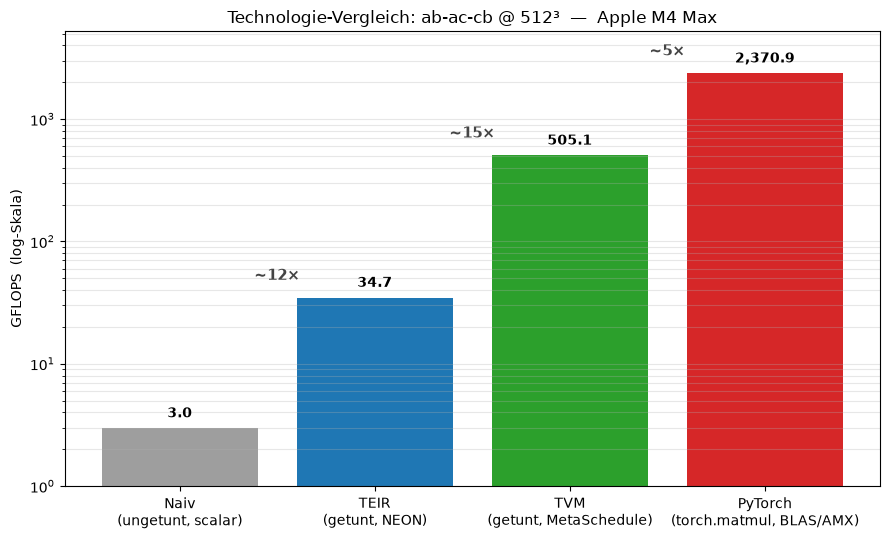

In [3]:
import matplotlib.pyplot as plt
labels = list(results.keys()); vals = list(results.values())
colors = ['#9e9e9e', '#1f77b4', '#2ca02c', '#d62728']
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, vals, color=colors)
ax.set_yscale('log')
ax.set_ylabel('GFLOPS  (log-Skala)')
ax.set_title(f'Technologie-Vergleich: {CASE} @ {N}\u00b3  \u2014  Apple M4 Max')
ax.set_ylim(1, max(vals) * 2.2)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v * 1.15, f'{v:,.1f}',
            ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3, which='both')
# Multiplikatoren zwischen den Balken (dynamisch aus den Messwerten)
for i, j in [(0, 1), (1, 2), (2, 3)]:
    ax.annotate(f'~{vals[j]/vals[i]:.0f}\u00d7', xy=(j, vals[j]),
                xytext=(i + 0.5, vals[j] * 1.4),
                ha='center', color='#444', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('hero_comparison.png', dpi=140)
plt.show()


## Was das zeigt (die ehrliche Story)

- **Naiv → TEIR: ~12×.** Unser Autotuner holt aus dem *gleichen, einfachen* Codegen das ~12-fache heraus — er **sucht wirklich** und findet gute Schedules (2,5 → 30,7 GFLOPS).
- **TEIR → TVM: ~19× — auf dem GLEICHEN Hardwarepfad (LLVM/NEON).** TVM nutzt mehrstufiges Cache-Tiling, Vektorisierung und Register-Blocking, das unser Codegen gar nicht *ausdrücken* kann. Das ist die ehrliche **Codegen-Decke**, kein Suchbudget-Problem.
- **TVM → PyTorch: ~4× — anderer Hardwarepfad.** `torch.matmul` ruft Apples BLAS → **AMX-Matrix-Coprozessor** (dediziertes Silizium), nicht die NEON-Vektoreinheiten. Kein Codegen-Wettbewerb, sondern spezialisierte Hardware.
- **Bonus:** `torch.einsum` (statt `torch.matmul`) liefert für denselben GEMM nur **~427 GFLOPS** — selbst *innerhalb* PyTorch entscheidet der API-Pfad drastisch.

**Take-away:** TEIR ist als **Suchverfahren** wirksam (~12× über naiv), hat aber eine niedrige **Codegen-Decke**. TVM beziffert, was mit besserem Codegen auf *gleicher* Hardware drin wäre; PyTorch/BLAS zeigt, was dedizierte Matrix-Hardware leistet. Unser Beitrag ist der ehrliche Autotuner + diese saubere Einordnung — nicht, BLAS zu schlagen.
